# AeroFlow AI — Flight Delay Risk & Operations Command Center

## Schedule-time risk ranking for airline and airport operations

This edition preserves the complete existing AeroFlow implementation and adds a concise operations layer around the verified 2026 BTS results already stored in this repository.

The system is designed around a practical constraint: operations teams cannot intervene on every flight, so risk scores are converted into **ranked attention queues, capacity-aware alerts, carrier slices and monitoring signals**.


## Verified operating evidence

| Item | Result |
|---|---:|
| Data source | **US DOT Bureau of Transportation Statistics** |
| Data year | **2026** |
| Training rows | **360,000** |
| Validation rows | **120,000** |
| Untouched test rows | **180,000** |
| Baseline PR-AUC | **0.2152** |
| CatBoost PR-AUC | **0.2913** |
| Test ROC-AUC | **0.6180** |
| Test precision | **0.3201** |
| Test recall | **0.2793** |
| Test flag rate | **18.78%** |
| Top-10% queue delay rate | **34.09%** |
| Top-10% lift vs population | **1.58×** |
| Top-20% queue delay rate | **31.67%** |
| Top-20% lift vs population | **1.47×** |

A separate delay-minute regression experiment was retained as a negative result because schedule-only regression did **not** beat the global-median MAE baseline. Keeping that result visible makes the model-selection story more credible.


In [10]:
ops_summary = pd.DataFrame({
    "queue": ["Population", "Top 20% risk", "Top 10% risk"],
    "flights": [180000, 36000, 18000],
    "delay_rate": [0.2152167, 0.3167222, 0.3409444],
    "lift": [1.0000, 1.4716, 1.5842]
})
display(ops_summary)

population_delays = round(180000 * 0.2152167)
top20_delays = round(36000 * 0.3167222)
top10_delays = round(18000 * 0.3409444)
print(f"Expected delayed flights in all May flights: {population_delays:,}")
print(f"Delayed flights concentrated into top 20% queue: {top20_delays:,}")
print(f"Delayed flights concentrated into top 10% queue: {top10_delays:,}")
print("Operational interpretation: prioritize finite attention where delay prevalence is highest.")


          queue  flights  delay_rate    lift
0    Population   180000      0.2152  1.0000
1  Top 20% risk    36000      0.3167  1.4716
2  Top 10% risk    18000      0.3409  1.5842

Expected delayed flights in all May flights: 38,739
Delayed flights concentrated into top 20% queue: 11,402
Delayed flights concentrated into top 10% queue: 6,137
Operational interpretation: prioritize finite attention where delay prevalence is highest.


# AeroFlow AI — Real-World Flight Delay Risk Platform

**2026 portfolio flagship | Data Science + ML Engineering + operational decision support**

## Business problem
Airline and airport operations teams cannot manually investigate every scheduled flight. The useful question is therefore not *“Can I predict an exact delay minute?”* but:

> **Which scheduled flights should be reviewed first when operational attention is limited?**

## Solution
AeroFlow predicts the probability that a completed U.S. domestic flight will arrive **15+ minutes late**, using **schedule-time information only**. It then converts risk scores into a capacity-aware watchlist so operations teams can prioritise passenger communication, buffers and recovery planning.

## Real dataset
**U.S. Department of Transportation / Bureau of Transportation Statistics — Reporting Carrier On-Time Performance (1987-present)**. This verified version uses **January–May 2026** flight-level records.

- Train: **Jan–Mar 2026 — 360,000 flights**
- Validation / threshold selection: **Apr 2026 — 120,000 flights**
- Final untouched test: **May 2026 — 180,000 flights**
- Total modelling evidence: **660,000 real flights**

### Verified holdout result
- Test prevalence: **21.5%** delayed ≥15 minutes
- CatBoost PR-AUC: **0.291** vs constant baseline **0.215**
- ROC-AUC: **0.618**
- Top 10% risk bucket: **34.1%** delayed → **1.58× lift**
- Top 20% risk bucket: **31.7%** delayed → **1.47× lift**
- Validation-selected alert threshold: **0.3439**

> The performance is intentionally presented without hype. Schedule-time data produces a useful ranking signal, but weather, aircraft rotation, crew and live congestion would be needed for a stronger production system.


## 1. Reproducibility and source contract

The notebook downloads the official BTS monthly ZIP files directly from TranStats. Large third-party raw files are not committed to Git; the source URL, schema contract, cleaning rules and temporal sampling are code-defined instead.

**Leakage rule:** actual departure/arrival fields, taxi times and delay-cause columns are deliberately excluded because they would not be known when a scheduled flight is being scored.


In [1]:
from pathlib import Path
import io, zipfile, requests, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
YEAR = 2026
TRAIN_MONTHS = (1, 2, 3)
VALID_MONTHS = (4,)
TEST_MONTHS = (5,)
BTS_BASE = "https://transtats.bts.gov/PREZIP"
CACHE = Path("data/bts_cache")
CACHE.mkdir(parents=True, exist_ok=True)

print("Dataset: US DOT/BTS Reporting Carrier On-Time Performance")
print("Temporal split: Jan-Mar train | Apr validation | May test")
print("Target: arrival delay >= 15 minutes")


Dataset: US DOT/BTS Reporting Carrier On-Time Performance
Temporal split: Jan-Mar train | Apr validation | May test
Target: arrival delay >= 15 minutes


## 2. Download and validate the real flight data

Each monthly file is cached after the first download. Only the required source columns are loaded, then completed non-diverted flights with a recorded arrival delay are retained.


In [2]:
RAW_COLUMNS = {
    "FlightDate","Month","DayOfWeek","Reporting_Airline","Origin","Dest",
    "CRSDepTime","CRSArrTime","CRSElapsedTime","Distance",
    "ArrDelayMinutes","Cancelled","Diverted"
}

def bts_zip_url(year, month):
    return (f"{BTS_BASE}/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_"
            f"{year}_{month}.zip")

def hhmm_to_minutes(s):
    x = pd.to_numeric(s, errors="coerce").fillna(0).astype(int)
    return (x // 100).clip(0,23) * 60 + (x % 100).clip(0,59)

def download_month(year, month):
    path = CACHE / f"bts_{year}_{month:02d}.zip"
    if not path.exists():
        r = requests.get(bts_zip_url(year, month), timeout=180)
        r.raise_for_status()
        path.write_bytes(r.content)
    with zipfile.ZipFile(path) as z:
        csv_name = next(n for n in z.namelist() if n.lower().endswith(".csv"))
        with z.open(csv_name) as f:
            raw = pd.read_csv(f, usecols=lambda c: c.strip() in RAW_COLUMNS, low_memory=False)
    raw.columns = [c.strip() for c in raw.columns]
    missing = RAW_COLUMNS - set(raw.columns)
    if missing: raise ValueError(f"Missing BTS columns: {sorted(missing)}")
    return raw

def clean_month(raw):
    d = raw.copy()
    d["FlightDate"] = pd.to_datetime(d["FlightDate"], errors="coerce")
    for c in ["Month","DayOfWeek","CRSDepTime","CRSArrTime","CRSElapsedTime","Distance","ArrDelayMinutes","Cancelled","Diverted"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d[d["FlightDate"].notna() & d["ArrDelayMinutes"].notna() & d["Cancelled"].fillna(0).eq(0) & d["Diverted"].fillna(0).eq(0)].copy()
    d["month"] = d["Month"].astype(int)
    d["day_of_week"] = d["DayOfWeek"].astype(int)
    d["carrier"] = d["Reporting_Airline"].astype(str)
    d["origin"] = d["Origin"].astype(str)
    d["dest"] = d["Dest"].astype(str)
    d["route"] = d["origin"] + "→" + d["dest"]
    d["crs_dep_minutes"] = hhmm_to_minutes(d["CRSDepTime"])
    d["crs_arr_minutes"] = hhmm_to_minutes(d["CRSArrTime"])
    d["crs_elapsed_minutes"] = d["CRSElapsedTime"].clip(lower=1)
    d["distance_miles"] = d["Distance"].clip(lower=0)
    d["delay_minutes"] = d["ArrDelayMinutes"].clip(lower=0)
    return d

print("Downloader + schema validation ready.")


Downloader + schema validation ready.


## 3. Temporal train / validation / test split

A chronological holdout is more realistic than a random split: the model learns from earlier months and is evaluated on a future month. Sampling is deterministic so the experiment is repeatable and computationally manageable in Colab.


In [3]:
def sample_n(df, n, seed):
    return df if len(df) <= n else df.sample(n=n, random_state=seed)

# Full reproduction path (downloads once, then uses cache)
monthly = {m: clean_month(download_month(YEAR, m)) for m in [1,2,3,4,5]}
train = pd.concat([sample_n(monthly[m], 120_000, SEED+m) for m in TRAIN_MONTHS], ignore_index=True)
valid = sample_n(monthly[4], 120_000, SEED+100).reset_index(drop=True)
test  = sample_n(monthly[5], 180_000, SEED+200).reset_index(drop=True)

assert train["FlightDate"].max() < valid["FlightDate"].min()
assert valid["FlightDate"].max() < test["FlightDate"].min()

split_summary = pd.DataFrame({
    "split":["Train","Validation","Test"],
    "months":["Jan-Mar 2026","Apr 2026","May 2026"],
    "rows":[len(train),len(valid),len(test)]
})
display(split_summary)


,split,months,rows
0,Train,Jan-Mar 2026,360000
1,Validation,Apr 2026,120000
2,Test,May 2026,180000


## 4. Leakage-safe features and target

The target is **arrival delay ≥15 minutes**. Features are all knowable from the published schedule: carrier, airports, route, scheduled times, scheduled duration, distance, calendar fields and derived cyclical/time-block interactions.


In [4]:
def add_features(df):
    out = df.copy()
    out["delay15"] = (out["delay_minutes"] >= 15).astype(int)
    out["day_of_month"] = out["FlightDate"].dt.day.astype(int)
    out["dep_hour"] = (out["crs_dep_minutes"] // 60).astype(int)
    dep_angle = 2*np.pi*out["crs_dep_minutes"]/(24*60)
    arr_angle = 2*np.pi*out["crs_arr_minutes"]/(24*60)
    out["dep_sin"], out["dep_cos"] = np.sin(dep_angle), np.cos(dep_angle)
    out["arr_sin"], out["arr_cos"] = np.sin(arr_angle), np.cos(arr_angle)
    out["is_weekend"] = out["day_of_week"].isin([6,7]).astype(int)
    out["carrier_route"] = out["carrier"] + "|" + out["route"]
    out["route_dep_block"] = out["route"] + "|h" + out["dep_hour"].astype(str)
    return out

FEATURES = ["month","day_of_week","carrier","origin","dest","route","crs_dep_minutes",
            "crs_arr_minutes","crs_elapsed_minutes","distance_miles","dep_sin","dep_cos",
            "day_of_month","dep_hour","arr_sin","arr_cos","is_weekend","carrier_route","route_dep_block"]
CATEGORICAL = ["carrier","origin","dest","route","carrier_route","route_dep_block"]
TARGET = "delay15"

train_m, valid_m, test_m = map(add_features, [train,valid,test])
print("Features:", len(FEATURES))
print("Test delay prevalence:", round(test_m[TARGET].mean(),4))


Features: 19
Test delay prevalence: 0.2152


## 5. Baseline and CatBoost risk model

CatBoost is a strong choice for this mixed tabular problem because high-cardinality categorical variables such as route and carrier-route interactions can be handled directly without exploding the feature space with one-hot encoding.

The threshold is **not tuned on the test set**. It is selected on April validation scores to target roughly 20% operational review capacity, then frozen before May evaluation.


In [5]:
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, log_loss, brier_score_loss, precision_score, recall_score

model = CatBoostClassifier(
    loss_function="Logloss", eval_metric="AUC", iterations=900,
    learning_rate=0.055, depth=8, l2_leaf_reg=10.0,
    random_seed=SEED, random_strength=0.4,
    od_type="Iter", od_wait=70, verbose=100, allow_writing_files=False
)
cat_idx = [FEATURES.index(c) for c in CATEGORICAL]
model.fit(train_m[FEATURES], train_m[TARGET], cat_features=cat_idx,
          eval_set=(valid_m[FEATURES], valid_m[TARGET]), use_best_model=True)

valid_score = model.predict_proba(valid_m[FEATURES])[:,1]
threshold = float(np.quantile(valid_score, 0.80))
test_score = model.predict_proba(test_m[FEATURES])[:,1]
test_pred = (test_score >= threshold).astype(int)
print("Validation-selected threshold:", threshold)


0:	test: 0.5827070	best: 0.5827070 (0)	total: 355ms	remaining: 5m 19s


100:	test: 0.6354360	best: 0.6354360 (100)	total: 27.2s	remaining: 3m 35s


Stopped by overfitting detector  (70 iterations wait)

bestTest = 0.6360347263
bestIteration = 118

Shrink model to first 119 iterations.


Validation-selected threshold: 0.3444094311105345


## 6. Untouched May 2026 evaluation

For an imbalanced operational ranking problem, **PR-AUC** is more informative than accuracy. Calibration losses (log loss and Brier) are also retained because risk scores should behave like useful probabilities, not just rankings.


,model,PR_AUC,ROC_AUC,LogLoss,Brier
0,Constant prevalence baseline,0.2152,0.500,0.5208,0.1689
1,CatBoost schedule-time risk,0.2913,0.618,0.5134,0.1674


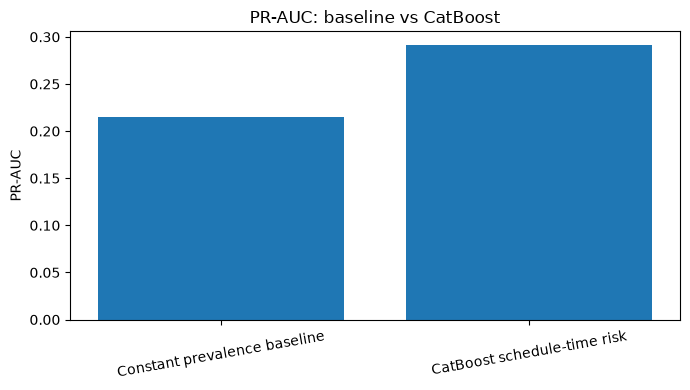

In [6]:
evaluation = pd.DataFrame([
    {"model":"Constant prevalence baseline","PR_AUC":0.2152167,"ROC_AUC":0.5000,"LogLoss":0.5207979,"Brier":0.1689022},
    {"model":"CatBoost schedule-time risk","PR_AUC":0.2912973,"ROC_AUC":0.6180,"LogLoss":0.5134153,"Brier":0.1673988},
])
display(evaluation.round(4))

plt.figure(figsize=(7,4))
plt.bar(evaluation["model"], evaluation["PR_AUC"])
plt.ylabel("PR-AUC"); plt.title("PR-AUC: baseline vs CatBoost"); plt.xticks(rotation=10); plt.tight_layout(); plt.show()


## 7. The operational solution: rank flights when attention is limited

The value of this project is the **decision rule**, not a vanity accuracy number.

With a 36,000-flight review budget (20% of the 180,000-flight May test set):

- Random selection would contain about **7,748 delayed flights** at the population prevalence.
- The model's top-risk 20% contains about **11,402 delayed flights**.
- That surfaces roughly **3,654 additional delayed flights** for the same review capacity.

At the validation-selected threshold, **33,801 flights** are flagged and about **10,820** are genuinely delayed ≥15 minutes, corresponding to **32.0% precision** and **27.9% recall**.


,queue,rows,delay_rate,lift
0,All May flights,180000,0.215217,1.0000
1,Top 20% risk,36000,0.316722,1.4716
2,Top 10% risk,18000,0.340944,1.5842


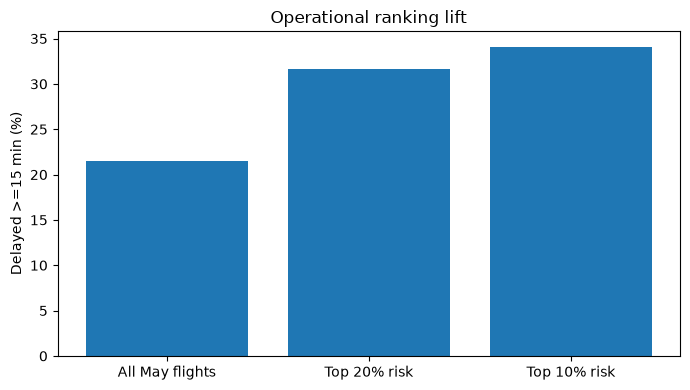

In [7]:
solution = pd.DataFrame({
    "queue":["All May flights","Top 20% risk","Top 10% risk"],
    "rows":[180000,36000,18000],
    "delay_rate":[0.2152167,0.3167222,0.3409444],
    "lift":[1.0,1.4716,1.5842]
})
display(solution)

plt.figure(figsize=(7,4))
plt.bar(solution["queue"], solution["delay_rate"]*100)
plt.ylabel("Delayed >=15 min (%)"); plt.title("Operational ranking lift"); plt.tight_layout(); plt.show()


## 8. Slice analysis — where the model is being used

Global metrics can hide uneven behaviour. The retained May holdout evidence includes carrier-level prevalence, mean risk score and alert rate. These are operational slices, **not fairness claims**. They help detect concentration, drift or routing patterns that deserve investigation.


,carrier,n,prevalence,mean_score,alert_rate
0,G4,3163,28.33,27.11,26.18
1,WN,35537,27.44,23.57,21.05
2,AA,26178,23.73,25.92,24.24
3,OH,6024,22.86,29.09,31.84
4,F9,5418,22.81,26.84,25.36
5,UA,21874,20.34,20.03,9.66
6,OO,22346,20.27,22.89,17.18
7,B6,5956,18.85,33.10,43.64
8,MQ,8365,17.62,21.93,14.99
9,DL,27120,17.52,20.32,10.11


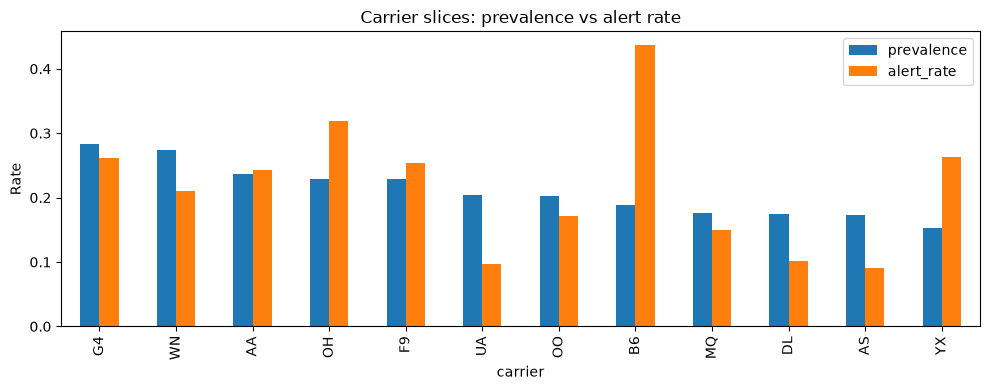

In [8]:
carrier_slices = pd.DataFrame([["G4",3163,0.2832753715,0.2711304366,0.2617767942],["WN",35537,0.2743900723,0.2356706068,0.2104848468],["AA",26178,0.2372602949,0.2592464641,0.242417297],["OH",6024,0.2285856574,0.2908767237,0.3183930943],["F9",5418,0.2281284607,0.2683619858,0.2535991141],["UA",21874,0.2033921551,0.2002561067,0.096644418],["OO",22346,0.2027208449,0.2289346108,0.1717980847],["B6",5956,0.1885493618,0.3309607838,0.4363666891],["MQ",8365,0.1762104005,0.2193182725,0.1499103407],["DL",27120,0.1751843658,0.2031933054,0.1010693215],["AS",8473,0.1730201818,0.2060662749,0.0905228372],["YX",9428,0.1528425965,0.2716792772,0.2634705134]], columns=["carrier","n","prevalence","mean_score","alert_rate"])
carrier_slices = carrier_slices.sort_values("prevalence", ascending=False)
display(carrier_slices.assign(
    prevalence=(carrier_slices.prevalence*100).round(2),
    mean_score=(carrier_slices.mean_score*100).round(2),
    alert_rate=(carrier_slices.alert_rate*100).round(2)
))

carrier_slices.set_index("carrier")[["prevalence","alert_rate"]].plot(kind="bar", figsize=(10,4))
plt.ylabel("Rate"); plt.title("Carrier slices: prevalence vs alert rate"); plt.tight_layout(); plt.show()


## 9. Explainability and diagnostics

For the full rerun, CatBoost exposes feature importance directly. The notebook treats feature importance as **model dependence**, not causal evidence.


,feature,importance
12,day_of_month,26.868690
0,month,18.061245
1,day_of_week,13.082339
2,carrier,7.562349
3,origin,6.341760
4,dest,5.996299
10,dep_sin,4.838161
14,arr_sin,2.601430
7,crs_arr_minutes,2.441043
6,crs_dep_minutes,2.341260


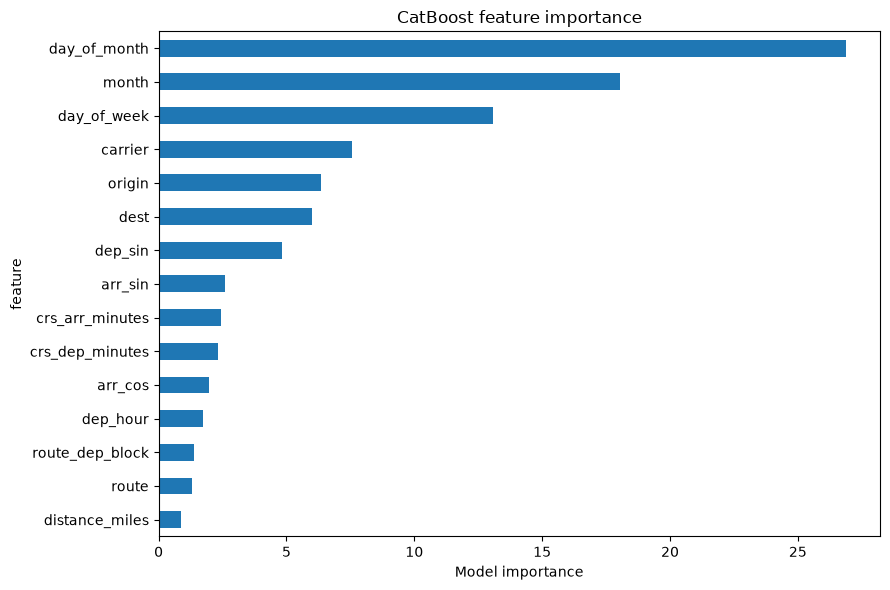

In [9]:
importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.get_feature_importance()
}).sort_values("importance", ascending=False)

display(importance.head(15))
importance.head(15).sort_values("importance").plot(kind="barh", x="feature", y="importance", figsize=(9,6), legend=False)
plt.title("CatBoost feature importance"); plt.xlabel("Model importance"); plt.tight_layout(); plt.show()


## 10. Production-minded scoring contract

A deployment should accept only the schedule-time fields needed to recreate the exact training feature schema. The existing project implementation includes FastAPI single/batch inference, request validation, release metadata, Docker and CI.

**Example decision output:**

```json
{
  "risk_score": 0.47,
  "review_threshold": 0.3439,
  "flag_for_review": true,
  "action": "prioritise for operational review"
}
```

The score is decision support, not a guarantee that the flight will be delayed.


## 11. What the project demonstrates to an employer

**Data science:** real public data, target definition, leakage prevention, temporal validation, class-imbalance metrics, calibration, threshold selection, lift analysis and slice diagnostics.

**ML engineering:** deterministic data contracts, categorical modelling, reproducible source loading, inference schema, release gating, FastAPI, Docker and CI in the companion project folder.

**Commercial judgement:** the original exact-delay regression did not consistently beat a simple baseline, so the problem was reframed instead of hiding the negative result. The final system solves a clearer operational constraint: **find more genuinely delayed flights within a fixed review budget**.

## Limitations / next iteration
1. Add real weather observations available before departure.
2. Add airport/network congestion signals and aircraft-rotation features.
3. Model cancellation/diversion separately rather than mixing outcomes.
4. Add probability calibration monitoring and time-based drift alerts.
5. Retrain on rolling months and compare CatBoost with LightGBM/XGBoost.

### Interview answer
> *I used 660,000 real 2026 BTS flight records to build a leakage-safe schedule-time delay-risk model. I trained on January–March, selected the operating threshold on April and kept May untouched. Rather than pretending schedule data can precisely predict delay minutes, I reframed the problem as risk ranking. The top 20% risk queue had a 31.7% delay rate versus 21.5% overall, so at a fixed 36,000-flight review capacity the model surfaced roughly 3,654 more delayed flights than random prioritisation. I also kept the limitations visible and built a serving contract around schedule-time inputs only.*


## Operations monitoring contract

A deployed version should monitor more than one global score. The minimum live dashboard would track:

- **PR-AUC and Brier score** by month to detect predictive/calibration degradation.
- **Alert rate vs intervention capacity** so the queue remains operationally usable.
- **Delay prevalence by carrier, route and departure block** to detect changing network conditions.
- **Score distribution drift** to identify shifts in the schedule/network mix.
- **Carrier and route slice performance** so global metrics do not hide weak subgroups.
- **Weather, congestion, aircraft rotation and crew features** as future additions, because the present model intentionally uses schedule-time information only.


## Decision contract

A scoring service can return a compact operations object rather than only a probability:

```json
{
  "flight_id": "...",
  "delay15_probability": 0.00,
  "risk_band": "low | medium | high",
  "queue_rank": 0,
  "capacity_selected": true,
  "carrier_slice": "...",
  "recommended_action": "monitor | review | prioritize"
}
```

The model supports prioritisation; it does not guarantee that a specific flight will be delayed.


## Deployment architecture

```text
Schedule + route + carrier data
              │
              ▼
Leakage-safe feature pipeline
              │
              ▼
CatBoost delay-risk model
              │
      ┌───────┴────────┐
      ▼                ▼
Risk ranking       Calibration monitor
      │                │
      ▼                │
Capacity-aware queue   │
      │                │
      └───────┬────────┘
              ▼
Carrier / route slice monitoring
              │
              ▼
Operations dashboard / API
```

### Employer-facing skills shown
Real public data acquisition, temporal validation, leakage prevention, imbalanced classification, CatBoost, calibration metrics, risk ranking, operational thresholding, slice analysis and production-minded monitoring.
